In [137]:
import cv2
import json
from matplotlib import pyplot as plt
import numpy as np
import os
import random

# import a lot of things from keras:
# sequential model
from keras.models import Sequential

from keras.layers import LeakyReLU

# layers
from keras.layers import Input, Dense, Dropout, Flatten, Conv2D, MaxPooling2D, RandomFlip, RandomRotation, RandomContrast, RandomBrightness

# loss function
from keras.metrics import categorical_crossentropy

# callback functions
from keras.callbacks import ReduceLROnPlateau, EarlyStopping

# convert data to categorial vector representation
from keras.utils import to_categorical

# nice progress bar for loading data
from tqdm.notebook import tqdm

# helper function for train/test split
from sklearn.model_selection import train_test_split

# import confusion matrix helper function
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# import pre-trained model
from keras.applications.vgg16 import VGG16

# include only those gestures
CONDITIONS = ['like', 'stop']

# image size
IMG_SIZE = 64
SIZE = (IMG_SIZE, IMG_SIZE)

# number of color channels we want to use
# set to 1 to convert to grayscale
# set to 3 to use color images
COLOR_CHANNELS = 3


## helper function to load and parse annotations

In [124]:
annotations = dict()

for condition in CONDITIONS:
    with open(f'../gesture_dataset_sample/_annotations/{condition}.json') as f:
        annotations[condition] = json.load(f)

In [125]:
first_key = list(annotations['like'].keys())[0]

print(json.dumps(annotations['like'][first_key], indent=2))

{
  "bboxes": [
    [
      0.38056273,
      0.35650891,
      0.17322347,
      0.10461114
    ]
  ],
  "labels": [
    "like"
  ],
  "landmarks": [
    [
      [
        0.5497169170918876,
        0.4276043615779976
      ],
      [
        0.5218336293004483,
        0.40536586667786917
      ],
      [
        0.48288133220125257,
        0.3930262243722419
      ],
      [
        0.4501841862302019,
        0.37981099195030416
      ],
      [
        0.44251365410099686,
        0.36620499322043343
      ],
      [
        0.43138297470865106,
        0.406093902776592
      ],
      [
        0.4072660997339628,
        0.4073950234480344
      ],
      [
        0.42588200316326846,
        0.40612291879594015
      ],
      [
        0.4441470003072778,
        0.4049221293588555
      ],
      [
        0.4314493576491367,
        0.4212979654419442
      ],
      [
        0.42096276272263283,
        0.4180224457320293
      ],
      [
        0.43966095717106257,
      

## helper function to pre-process images (color channel conversion and resizing)

In [126]:
def preprocess_image(img):
    if COLOR_CHANNELS == 1:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img_resized = cv2.resize(img, SIZE)
    return img_resized

## load images and annotations

In [127]:
images = [] # stores actual image data
labels = [] # stores labels (as integer - because this is what our network needs)
label_names = [] # maps label ints to their actual categories so we can understand predictions later

# loop over all conditions
# loop over all files in the condition's directory
# read the image and corresponding annotation
# crop image to the region of interest
# preprocess image
# store preprocessed image and label in corresponding lists
for condition in CONDITIONS:
    for filename in tqdm(os.listdir(f'../gesture_dataset_sample/{condition}')):
        # extract unique ID from file name
        UID = filename.split('.')[0]
        img = cv2.imread(f'../gesture_dataset_sample/{condition}/{filename}')
        
        # get annotation from the dict we loaded earlier
        try:
            annotation = annotations[condition][UID]
        except Exception as e:
            print(e)
            continue
        
        # iterate over all hands annotated in the image
        for i, bbox in enumerate(annotation['bboxes']):
            # annotated bounding boxes are in the range from 0 to 1
            # therefore we have to scale them to the image size
            x1 = int(bbox[0] * img.shape[1])
            y1 = int(bbox[1] * img.shape[0])
            w = int(bbox[2] * img.shape[1])
            h = int(bbox[3] * img.shape[0])
            x2 = x1 + w
            y2 = y1 + h
            
            # crop image to the bounding box and apply pre-processing
            crop = img[y1:y2, x1:x2]
            preprocessed = preprocess_image(crop)
            
            # get the annotated hand's label
            # if we have not seen this label yet, add it to the list of labels
            label = annotation['labels'][i]
            if label == "no_gesture":
                continue
            if label not in label_names:
                label_names.append(label)
            
            label_index = label_names.index(label)
            
            images.append(preprocessed)
            labels.append(label_index)

  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

## let's have a look at one of the images

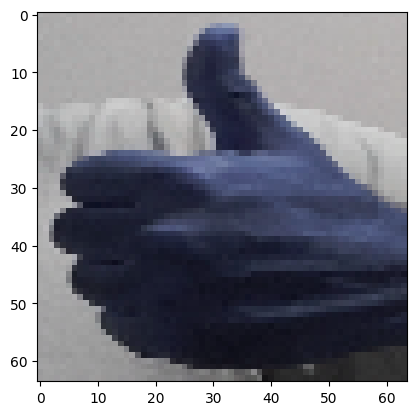

In [128]:
plt.imshow(random.sample(images, 1)[0])

## split data set into train and test

x is for the actual data, y is for the label (this is convention)

In [129]:
X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)

print(len(X_train))
print(len(X_test))
print(len(y_train))
print(len(y_test))

400
100
400
100


## transform data sets into a format compatible with our neural network

image data has to be a numpy array with following dimensions: [image_id, y_axis, x_axis, color_channels]

furthermore, scale all values to a range of 0 to 1

training data has to be converted to a categorial vector ("one hot"):

[3] --> [0, 0, 0, 1, 0, ..., 0]

In [130]:
X_train = np.array(X_train).astype('float32')
X_train = X_train / 255.

X_test = np.array(X_test).astype('float32')
X_test = X_test / 255.

y_train_one_hot = to_categorical(y_train)
y_test_one_hot = to_categorical(y_test)

train_label = y_train_one_hot
test_label = y_test_one_hot

X_train = X_train.reshape(-1, IMG_SIZE, IMG_SIZE, COLOR_CHANNELS)
X_test = X_test.reshape(-1, IMG_SIZE, IMG_SIZE, COLOR_CHANNELS)

print(X_train.shape, X_test.shape, train_label.shape, test_label.shape)

(400, 64, 64, 3) (100, 64, 64, 3) (400, 2) (100, 2)


## Apply Different Data Augmentations ##

In [131]:
augmentations = {
    "none" : [],
    "flip" : [RandomFlip('horizontal')],
    "contrast" : [RandomContrast(0.1)],
    "brightness" : [RandomBrightness(0.1)],
    "rotation" : [RandomRotation(0.2)],
    "flip_contrast" : [RandomFlip('horizontal'), RandomContrast(0.1)],
    "flip_contrast_rotation" : [RandomFlip('horizontal'), RandomContrast(0.1), RandomRotation(0.2)],
    "rotation_brightness": [RandomRotation(0.2), RandomBrightness(0.1)],
    "rotation_brightness_flip": [RandomRotation(0.2), RandomBrightness(0.1), RandomFlip('horizontal')],
    "all" : [RandomFlip('horizontal'), RandomContrast(0.1), RandomBrightness(0.1), RandomRotation(0.2)]
}
    

In [132]:
# variables for hyperparameters
batch_size = 8
epochs = 50
num_classes = len(label_names)
activation = 'relu'
layer_count = 2
num_neurons = 64
dropout = 0.05

In [138]:
def build_model(augmentation, augmentations=augmentations):
    model = Sequential()
    
    for aug in augmentations[augmentation]:
        model.add(aug)
        
    model.add(Conv2D(64, kernel_size=(9, 9), input_shape=(SIZE[0], SIZE[1], COLOR_CHANNELS), padding='same'))
    model.add(LeakyReLU())
    model.add(MaxPooling2D(pool_size=(4, 4), padding='same'))

    model.add(Conv2D(32, (5, 5), padding='same'))
    model.add(LeakyReLU())
    model.add(MaxPooling2D(pool_size=(3, 3), padding='same'))

    model.add(Conv2D(32, (3, 3), padding='same'))
    model.add(LeakyReLU())
    model.add(MaxPooling2D(pool_size=(2, 2), padding='same'))

    model.add(Dropout(0.2))

    model.add(Flatten())

    for i in range(layer_count - 1):
        model.add(Dense(num_neurons, activation=activation))

    model.add(Dense(num_neurons, activation=activation))

    model.add(Dense(num_classes, activation='softmax'))

    model.compile(loss=categorical_crossentropy, optimizer="adam", metrics=['accuracy'])
    
    return model

In [139]:

import time
def train_and_evaluate(augmentations, aug_dict):
    results = []
    for augmentation in augmentations:
        model = build_model(augmentation, aug_dict)
        reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=0.0001)
        
        start_train_time = time.time()
        history = model.fit(
            X_train,
            train_label,
            batch_size=batch_size,
            epochs=epochs,
            verbose=1,
            validation_data=(X_test, test_label),
            callbacks=[reduce_lr]
        )
        training_time = time.time() - start_train_time
        
        loss = history.history['loss']
        val_loss = history.history['val_loss']
        accuracy = history.history['accuracy']
        val_accuracy = history.history['val_accuracy']
        
        start_predict_time = time.time()
        y_predictions = model.predict(X_test)
        prediction_time = time.time() - start_predict_time
        
        results.append({
            "augmentation": augmentation,
            "loss": loss,
            "val_loss": val_loss,
            "accuracy": accuracy,
            "val_accuracy": val_accuracy,
            "model": model,
            "training_time": training_time,
            "prediction_time": prediction_time
        })
        
        
    return results

In [140]:
results = train_and_evaluate(augmentations.keys(), augmentations)

Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.5475 - loss: 0.7047 - val_accuracy: 0.4600 - val_loss: 0.7075 - learning_rate: 0.0010
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.6750 - loss: 0.5685 - val_accuracy: 0.8700 - val_loss: 0.3033 - learning_rate: 0.0010
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8000 - loss: 0.4377 - val_accuracy: 0.9600 - val_loss: 0.3127 - learning_rate: 0.0010
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8875 - loss: 0.2562 - val_accuracy: 0.9700 - val_loss: 0.1324 - learning_rate: 0.0010
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9350 - loss: 0.1954 - val_accuracy: 0.9400 - val_loss: 0.1367 - learning_rate: 0.0010
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9525 - loss: 0.1247 - val_accuracy: 0.9600 - val_loss: 0.0973 - learning_rate: 0.0010
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9275 - loss: 0.1784 - val_acc

# Analysis #

### Approach ###

I tested different data augmentation configurations based on Flip, Contrast, Brightness, and Rotation. Besides testing each augmentation individually, I also tested several combinations as well as a baseline model without augmentation. For all experiments, the same CNN architecture and training parameters were used. Early stopping was disabled so that all models were trained for the same number of epochs.

### Assumptions ###

I assume that data augmentation can improve generalization because the model sees more variations of the training images. Without augmentation, I expect the model to be more prone to overfitting and therefore perform worse on unseen data.

I also assume that there is an optimal amount of augmentation. Too little augmentation may not provide enough variation, while too much augmentation could make the images unrealistic and negatively affect performance.

## Results ##

In [141]:
import pandas as pd
df = pd.DataFrame([
    {
        "augmentation": r["augmentation"],
        "accuracy": r["accuracy"][-1],
        "val_accuracy": r["val_accuracy"][-1],
        "max_val_accuracy": max(r["val_accuracy"]),
        "training_time": r["training_time"],
        "prediction_time": r["prediction_time"]
    }
    for r in results
])

df.sort_values("max_val_accuracy", ascending=False)

,augmentation,accuracy,val_accuracy,max_val_accuracy,training_time,prediction_time
6,flip_contrast_rotation,0.9700,1.00,1.00,58.432388,0.176738
1,flip,0.9900,0.99,0.99,51.120187,0.143343
2,contrast,1.0000,0.99,0.99,58.667383,0.178866
5,flip_contrast,1.0000,0.99,0.99,57.794238,0.168414
0,none,1.0000,0.97,0.98,48.917028,0.127729
4,rotation,0.9650,0.98,0.98,94.120297,0.240846
8,rotation_brightness_flip,0.5025,0.46,0.61,57.540718,0.176418
7,rotation_brightness,0.4775,0.46,0.60,56.838535,0.172617
9,all,0.5200,0.46,0.58,59.262490,0.185514
3,brightness,0.5025,0.46,0.52,58.272726,0.269207


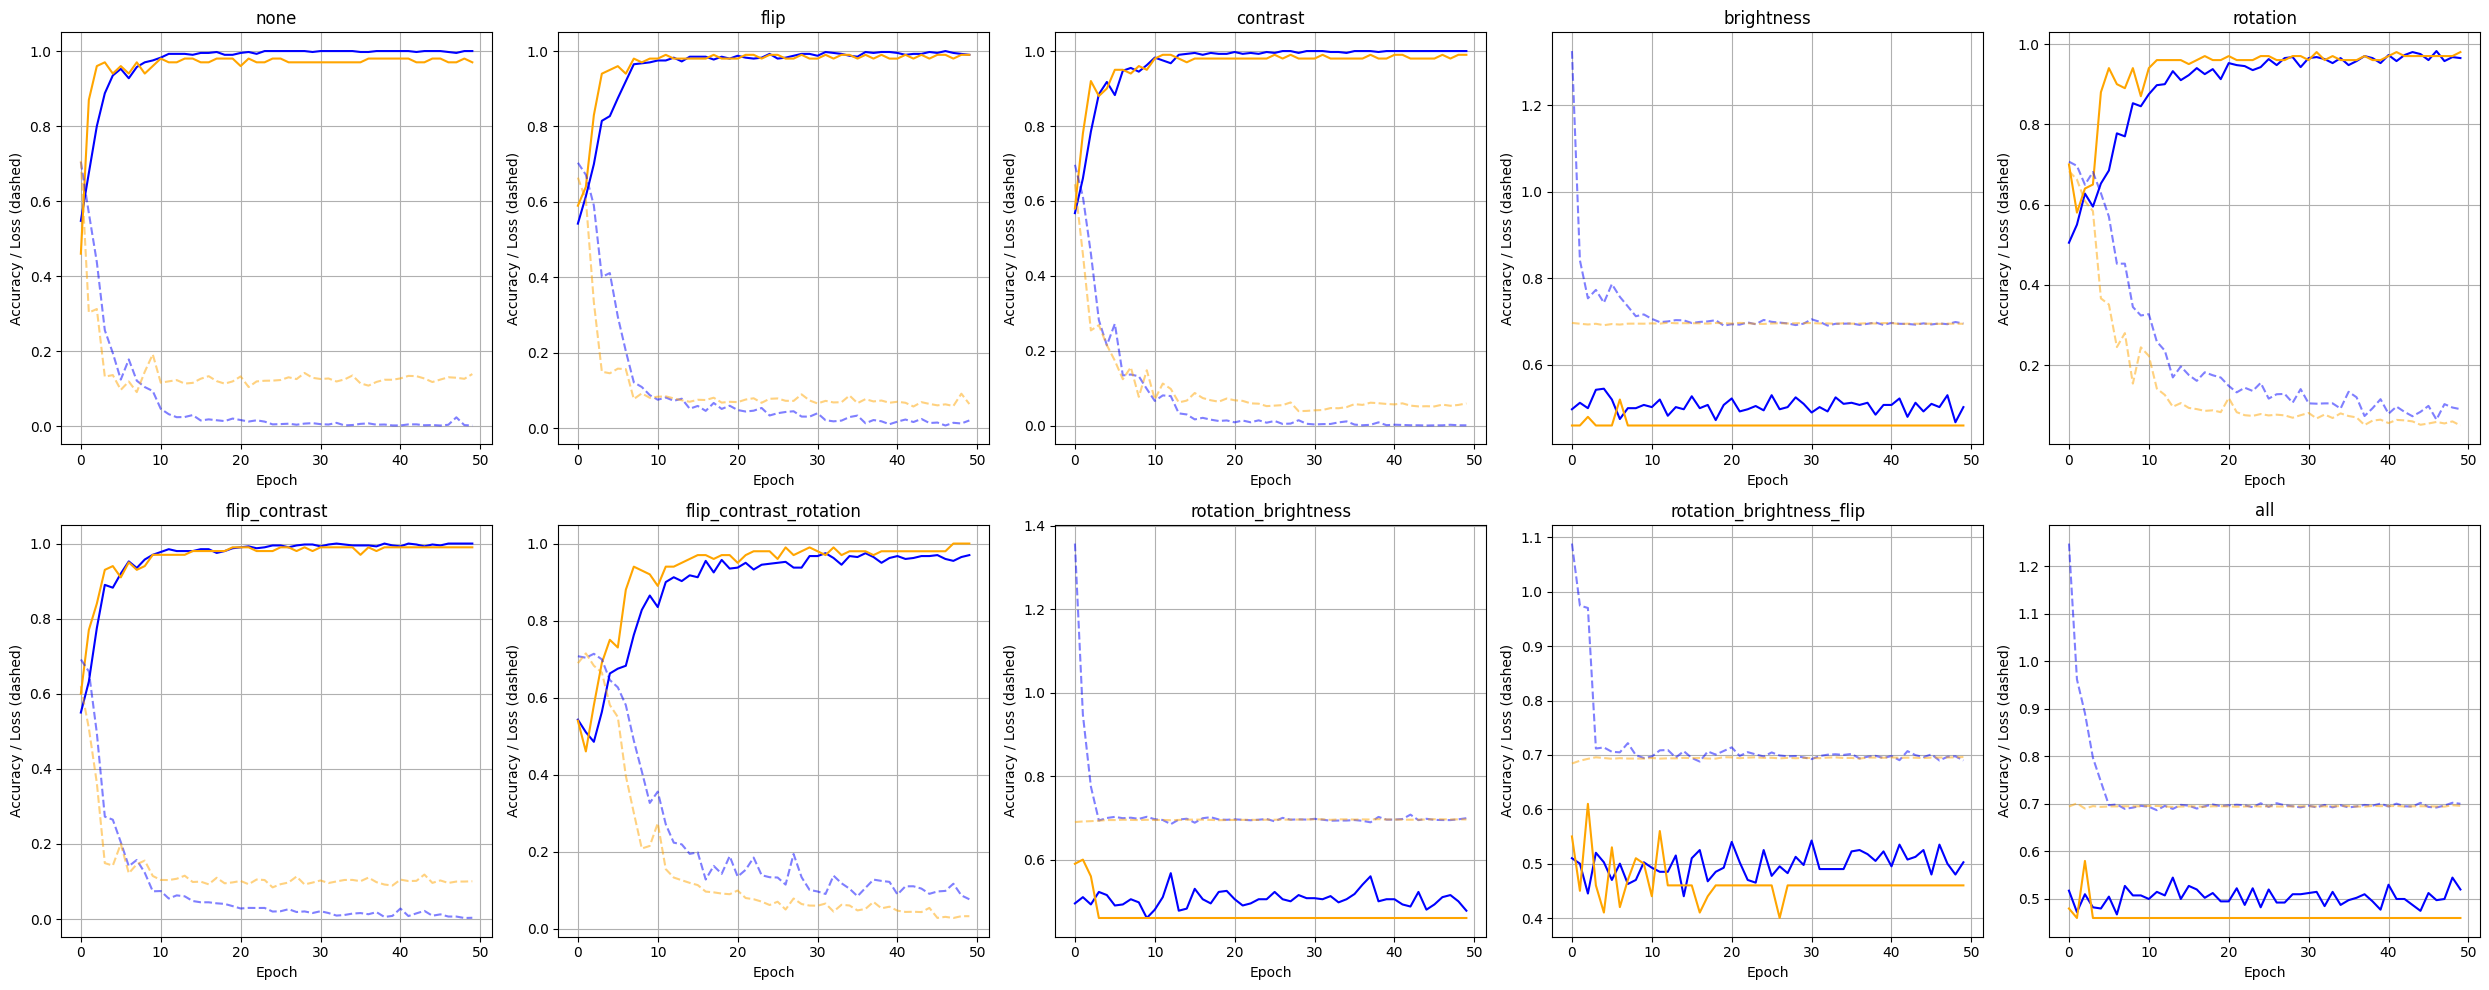

In [142]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 5, figsize=(25, 10))

axes = axes.flatten()

for ax, result in zip(axes, results):

    ax.plot(result['accuracy'], color='blue', label='train acc')
    ax.plot(result['val_accuracy'], color='orange', label='val acc')
    ax.plot(result['loss'], '--', color='blue', alpha=0.5)
    ax.plot(result['val_loss'], '--', color='orange', alpha=0.5)
    ax.set_title(result['augmentation'])
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy / Loss (dashed)')

    ax.grid(True)

plt.tight_layout()

plt.show()

Most augmentation configurations achieved validation accuracies close to 1.0 and converged within the first few epochs. Flip, Contrast, and their combination showed fast and stable learning behavior. Rotation required more epochs and had stronger fluctuations during training, but still reached a high validation accuracy. In contrast, all configurations containing Brightness augmentation failed to learn meaningful representations and remained close to random guessing with validation accuracies around 0.46–0.50. These results suggest that, under the chosen augmentation settings, Brightness augmentation had a strongly negative effect on model performance, whereas Flip, Contrast, and Rotation generally improved or maintained the classifier’s accuracy.

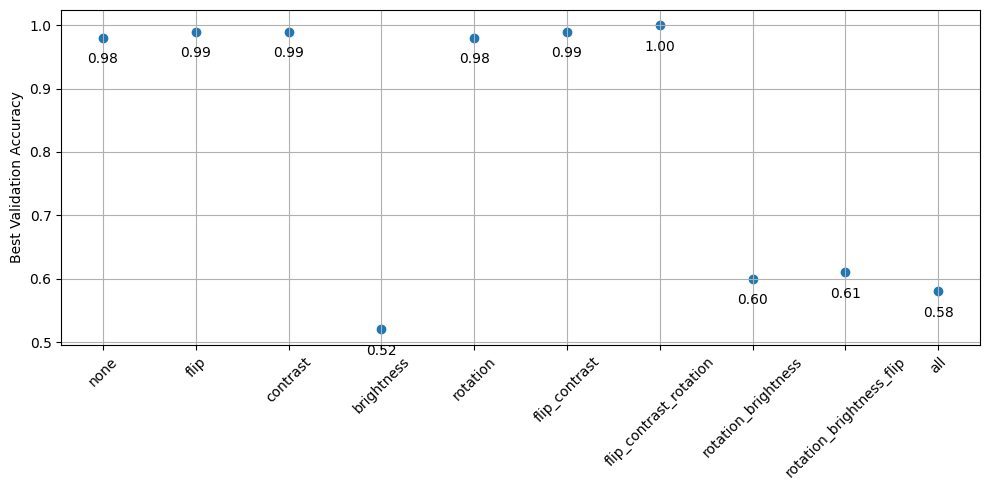

In [ ]:
# Created this with ChatGPT
plt.figure(figsize=(10,5))

plt.scatter(
    range(len(df)),
    df["max_val_accuracy"]
)



for i, value in enumerate(df["max_val_accuracy"]):
    plt.text(
        i,
        value - 0.04,     # etwas oberhalb des Punkts
        f"{value:.2f}",
        ha="center"
    )

plt.xticks(
    range(len(df)),
    df["augmentation"],
    rotation=45
)

plt.ylabel("Best Validation Accuracy")
plt.grid(True)
plt.tight_layout()
plt.show()

The best validation accuracies were achieved by the Flip, Contrast, and Flip-Contrast-Rotation configurations, while all augmentations containing Brightness performed substantially worse.

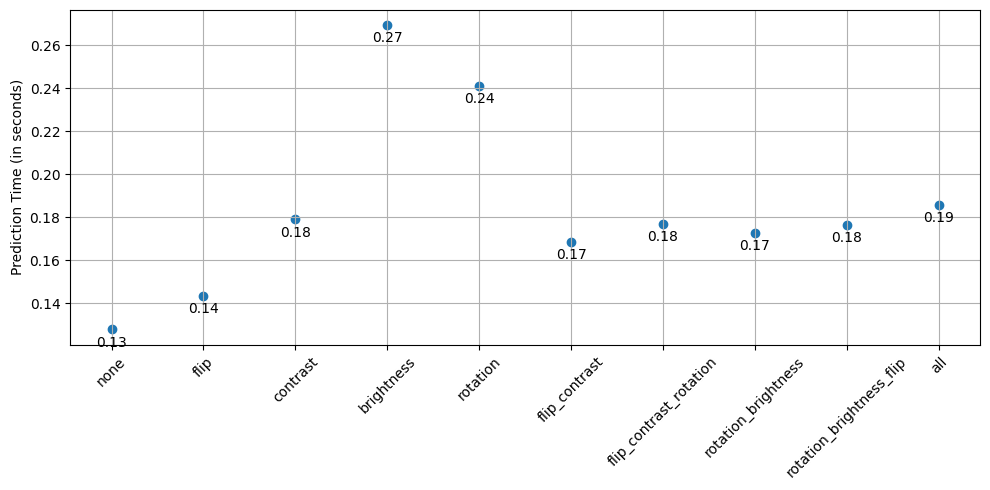

In [ ]:
# Created this with ChatGPT
plt.figure(figsize=(10,5))

plt.scatter(
    range(len(df)),
    df["prediction_time"]
)


for i, value in enumerate(df["prediction_time"]):
    plt.text(
        i,
        value - 0.008,     
        f"{value:.2f}",
        ha="center"
    )

plt.xticks(
    range(len(df)),
    df["augmentation"],
    rotation=45
)

plt.ylabel("Prediction Time (in seconds)")
plt.grid(True)
plt.tight_layout()
plt.show()

Prediction times ranged from approximately 0.13 s to 0.27 s. While the absolute differences are relatively small, a noticeable variation between the tested configurations can be observed. Interestingly, the model without augmentation achieved the lowest prediction time. These results are kind of unexpected, as data augmentation is only applied during training and not during prediction. Therefore, the observed differences are likely caused by runtime fluctuations rather than the augmentation itself.

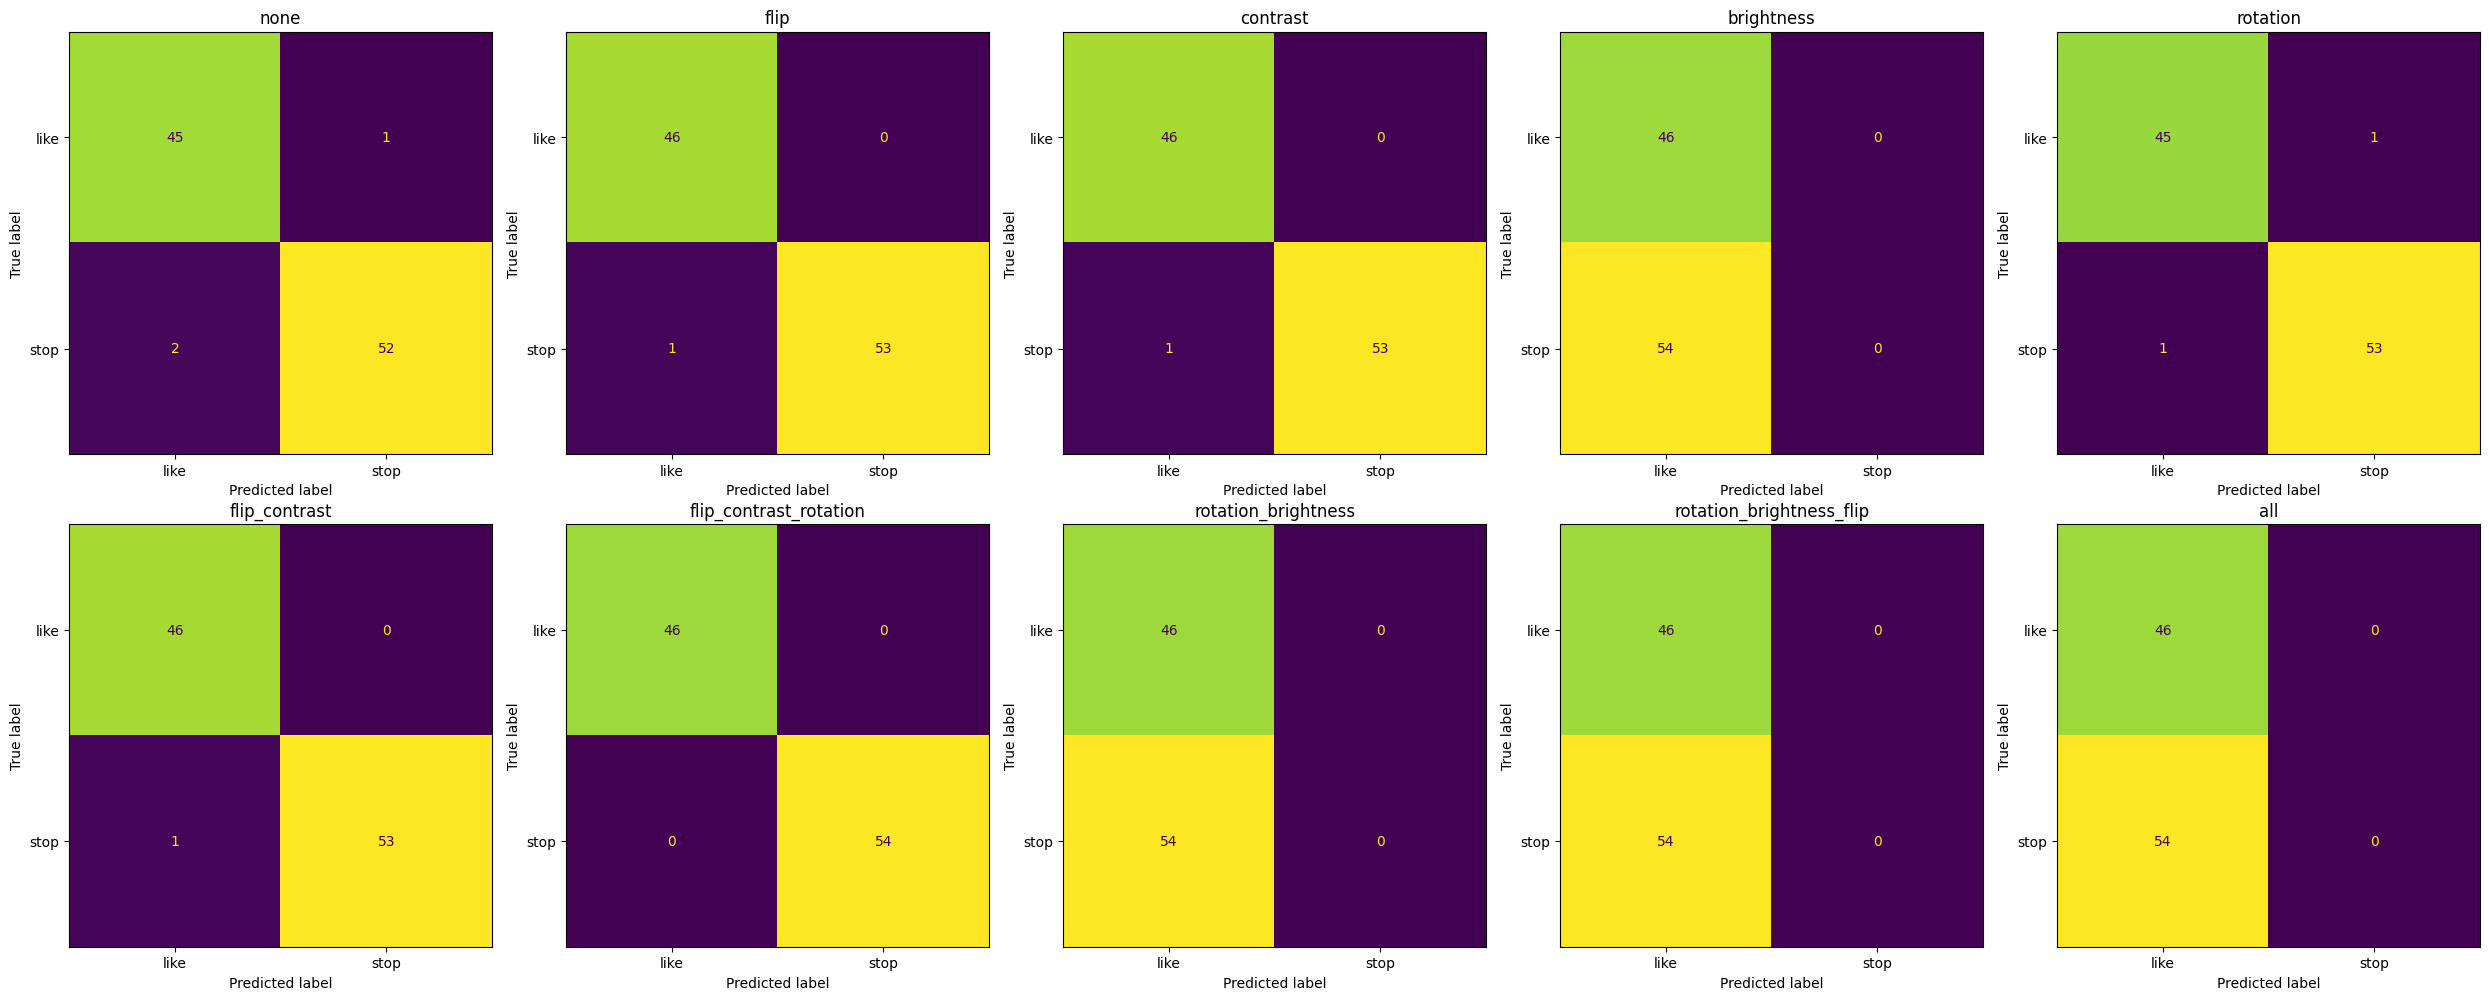

In [145]:
fig, axes = plt.subplots(2, 5, figsize=(25, 10))
axes = axes.flatten()

for ax, result in zip(axes, results):

    model = result["model"]

    y_pred = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_pred, axis=1)

    conf_matrix = confusion_matrix(y_test, y_pred)

    ConfusionMatrixDisplay(
        conf_matrix,
        display_labels=label_names
    ).plot(ax=ax, colorbar=False)

    ax.set_title(result["augmentation"])

plt.tight_layout()
plt.show()

The confusion matrices are consistent with the validation accuracy results. The model without any augmentation, Flip, Contrast, Rotation, and most combinations without Brightness classified almost all samples correctly. In contrast, the configurations containing Brightness augmentation performed poorly and consistently predicted only one class. This indicates that these models failed to learn a meaningful decision boundary between the two gesture classes.

One notable observation is that the baseline model without any data augmentation already achieved a very high validation accuracy. This is  surprising, as i expected that data augmentation generally improves generalization performance by exposing the model to a wider variety of training examples.

One possible explanation for the strong performance of the model without augmentation is that the dataset already contains sufficient variation in hand appearances, backgrounds, and lighting conditions. Furthermore, the two gesture classes are visually distinct, making the classification task relatively simple. As a result, additional augmentation provides only limited benefits because the model is already able to generalize well from the original training data.